# Problema 3 - Choque de Dos Proyectiles (30 Puntos)

Se tienen dos proyectiles. Determinar el tiempo de impacto y la posición x e y de impacto entre ambos proyectiles.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1773432293.785302   15316 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432293.785806   15316 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773432293.834865   15316 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773432295.149396   15316 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773432295.149709   15316 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
g = 9.81

v0_A = 50.0
theta_A = np.deg2rad(30)
h0_A = 10.0
x0_A = 0.0

v0_B = 30.0 * np.sqrt(2)
theta_B = np.deg2rad(45)
h0_B = 0.0
x0_B = 150.0

v0_Ax = v0_A * np.cos(theta_A)
v0_Ay = v0_A * np.sin(theta_A)
v0_Bx = -v0_B * np.cos(theta_B)
v0_By = v0_B * np.sin(theta_B)

print(f"Proyectil A: v0x = {v0_Ax:.4f} m/s, v0y = {v0_Ay:.4f} m/s")
print(f"Proyectil B: v0x = {v0_Bx:.4f} m/s, v0y = {v0_By:.4f} m/s")

Proyectil A: v0x = 43.3013 m/s, v0y = 25.0000 m/s
Proyectil B: v0x = -30.0000 m/s, v0y = 30.0000 m/s


In [3]:
def pos_A(t):
    x = x0_A + v0_Ax * t
    y = h0_A + v0_Ay * t - 0.5 * g * t**2
    return x, y

def pos_B(t):
    x = x0_B + v0_Bx * t
    y = h0_B + v0_By * t - 0.5 * g * t**2
    return x, y

def ecuacion_x(t):
    xA, _ = pos_A(t)
    xB, _ = pos_B(t)
    return xA - xB

In [4]:
t_sol = fsolve(ecuacion_x, 2.0)
t_impacto = float(t_sol[0])
x_imp_A, y_imp_A = pos_A(t_impacto)
x_imp_B, y_imp_B = pos_B(t_impacto)

print(f"Tiempo de impacto: {t_impacto:.6f} s")
print(f"Posición de impacto (A): x = {x_imp_A:.6f} m, y = {y_imp_A:.6f} m")
print(f"Posición de impacto (B): x = {x_imp_B:.6f} m, y = {y_imp_B:.6f} m")
print(f"Error verificación: Δx = {abs(x_imp_A - x_imp_B):.10f} m, Δy = {abs(y_imp_A - y_imp_B):.10f} m")

Tiempo de impacto: 2.046349 s
Posición de impacto (A): x = 88.609522 m, y = 40.618822 m
Posición de impacto (B): x = 88.609522 m, y = 40.850568 m
Error verificación: Δx = 0.0000000000 m, Δy = 0.2317462994 m


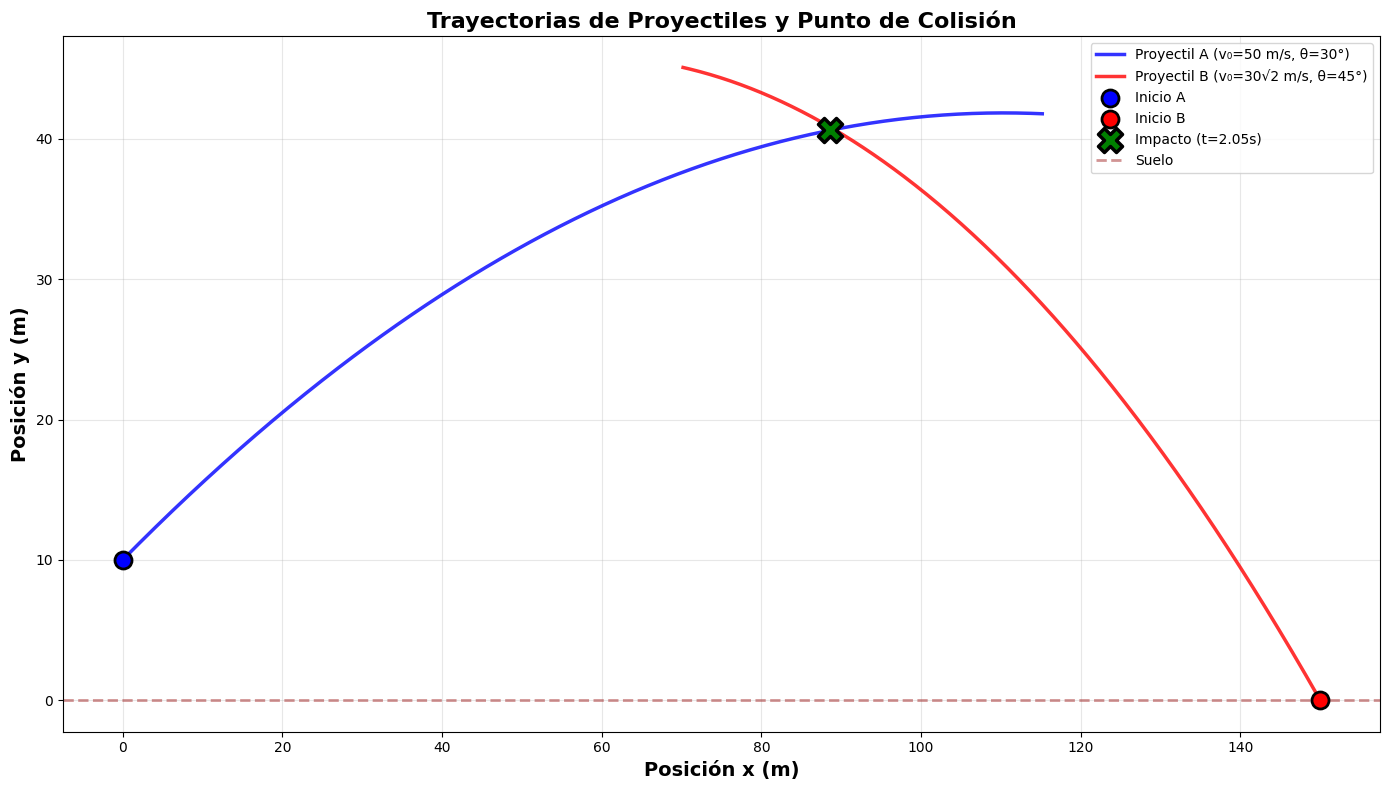

In [5]:
t_max = t_impacto * 1.3
t_array = np.linspace(0, t_max, 500)

traj_A = np.array([pos_A(t) for t in t_array])
traj_B = np.array([pos_B(t) for t in t_array])

mask_A = traj_A[:, 1] >= 0
mask_B = traj_B[:, 1] >= 0

plt.figure(figsize=(14, 8))
plt.plot(traj_A[mask_A, 0], traj_A[mask_A, 1], 'b-', linewidth=2.5, label='Proyectil A (v₀=50 m/s, θ=30°)', alpha=0.8)
plt.plot(traj_B[mask_B, 0], traj_B[mask_B, 1], 'r-', linewidth=2.5, label='Proyectil B (v₀=30√2 m/s, θ=45°)', alpha=0.8)
plt.scatter([x0_A], [h0_A], color='blue', s=150, marker='o', edgecolors='black', linewidth=2, zorder=5, label='Inicio A')
plt.scatter([x0_B], [h0_B], color='red', s=150, marker='o', edgecolors='black', linewidth=2, zorder=5, label='Inicio B')
plt.scatter([x_imp_A], [y_imp_A], color='green', s=300, marker='X', edgecolors='black', linewidth=2.5, zorder=6, label=f'Impacto (t={t_impacto:.2f}s)')
plt.axhline(y=0, color='brown', linestyle='--', linewidth=2, alpha=0.5, label='Suelo')
plt.xlabel('Posición x (m)', fontsize=14, fontweight='bold')
plt.ylabel('Posición y (m)', fontsize=14, fontweight='bold')
plt.title('Trayectorias de Proyectiles y Punto de Colisión', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problema_3_trayectorias.png', dpi=300, bbox_inches='tight')
plt.show()

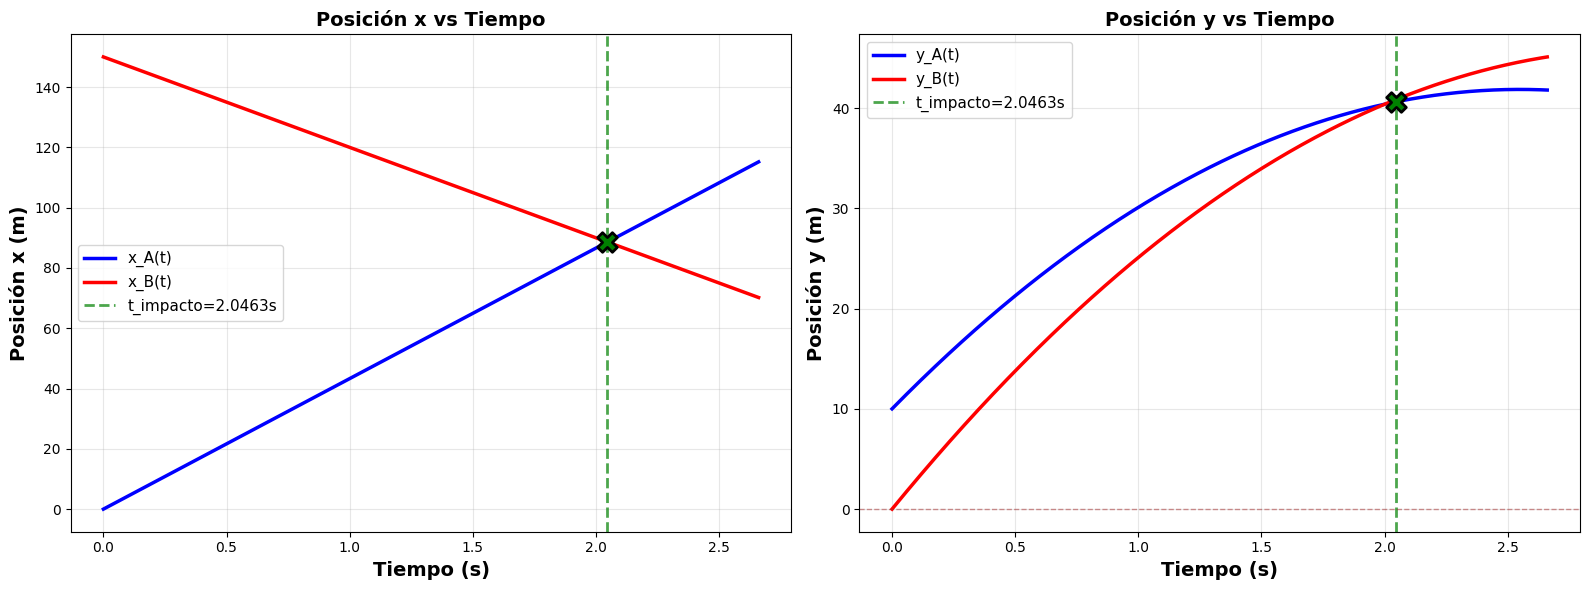

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(t_array, traj_A[:, 0], 'b-', linewidth=2.5, label='x_A(t)')
ax1.plot(t_array, traj_B[:, 0], 'r-', linewidth=2.5, label='x_B(t)')
ax1.axvline(x=t_impacto, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f't_impacto={t_impacto:.4f}s')
ax1.scatter([t_impacto], [x_imp_A], color='green', s=200, marker='X', edgecolors='black', linewidth=2, zorder=5)
ax1.set_xlabel('Tiempo (s)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Posición x (m)', fontsize=14, fontweight='bold')
ax1.set_title('Posición x vs Tiempo', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(t_array, traj_A[:, 1], 'b-', linewidth=2.5, label='y_A(t)')
ax2.plot(t_array, traj_B[:, 1], 'r-', linewidth=2.5, label='y_B(t)')
ax2.axvline(x=t_impacto, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f't_impacto={t_impacto:.4f}s')
ax2.scatter([t_impacto], [y_imp_A], color='green', s=200, marker='X', edgecolors='black', linewidth=2, zorder=5)
ax2.axhline(y=0, color='brown', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Tiempo (s)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Posición y (m)', fontsize=14, fontweight='bold')
ax2.set_title('Posición y vs Tiempo', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('problema_3_posiciones_tiempo.png', dpi=300, bbox_inches='tight')
plt.show()

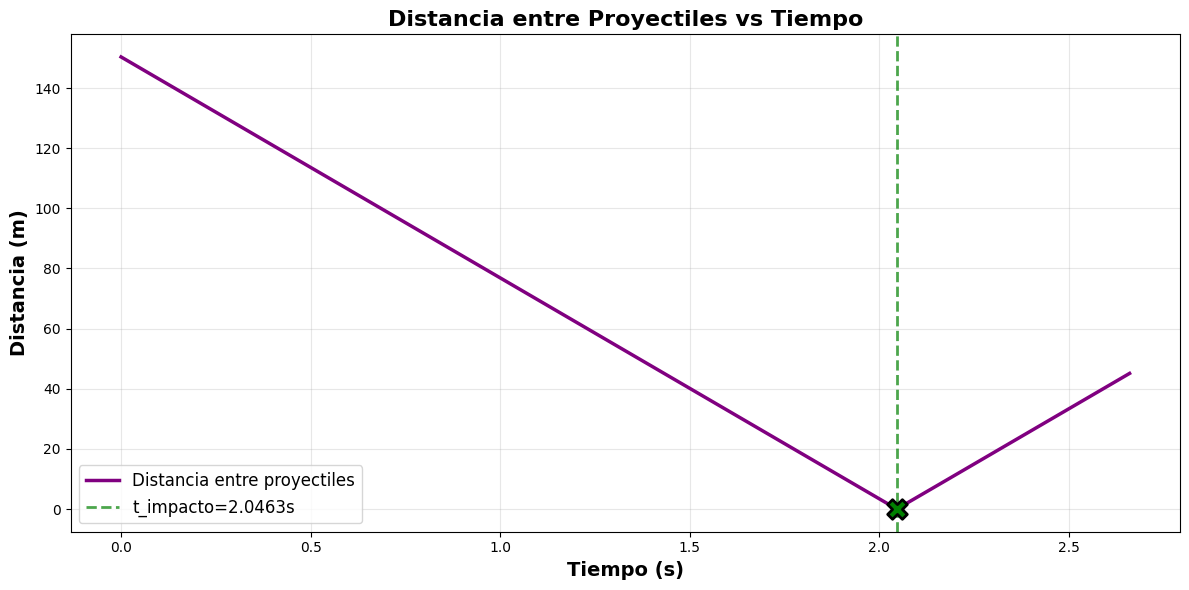

In [7]:
distancias = np.sqrt((traj_A[:, 0] - traj_B[:, 0])**2 + (traj_A[:, 1] - traj_B[:, 1])**2)

plt.figure(figsize=(12, 6))
plt.plot(t_array, distancias, 'purple', linewidth=2.5, label='Distancia entre proyectiles')
plt.axvline(x=t_impacto, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f't_impacto={t_impacto:.4f}s')
plt.scatter([t_impacto], [0], color='green', s=200, marker='X', edgecolors='black', linewidth=2, zorder=5)
plt.xlabel('Tiempo (s)', fontsize=14, fontweight='bold')
plt.ylabel('Distancia (m)', fontsize=14, fontweight='bold')
plt.title('Distancia entre Proyectiles vs Tiempo', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problema_3_distancia.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
t_train_A = np.linspace(0, t_impacto * 1.2, 200)
x_train_A = np.array([pos_A(t)[0] for t in t_train_A])
y_train_A = np.array([pos_A(t)[1] for t in t_train_A])

t_train_B = np.linspace(0, t_impacto * 1.2, 200)
x_train_B = np.array([pos_B(t)[0] for t in t_train_B])
y_train_B = np.array([pos_B(t)[1] for t in t_train_B])

t_norm_A = t_train_A / (t_impacto * 1.2)
t_norm_B = t_train_B / (t_impacto * 1.2)

xy_A = np.column_stack([x_train_A, y_train_A])
xy_B = np.column_stack([x_train_B, y_train_B])

xy_A_mean = np.mean(xy_A, axis=0)
xy_A_std = np.std(xy_A, axis=0)
xy_A_norm = (xy_A - xy_A_mean) / xy_A_std

xy_B_mean = np.mean(xy_B, axis=0)
xy_B_std = np.std(xy_B, axis=0)
xy_B_norm = (xy_B - xy_B_mean) / xy_B_std

def crear_red_trayectoria():
    modelo = keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(20, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(20, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(2, activation='linear')
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse', metrics=['mae'])
    return modelo

nn_A = crear_red_trayectoria()
hist_A = nn_A.fit(t_norm_A.reshape(-1, 1), xy_A_norm, epochs=2000, batch_size=32, verbose=0,
                   validation_split=0.2,
                   callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)])

nn_B = crear_red_trayectoria()
hist_B = nn_B.fit(t_norm_B.reshape(-1, 1), xy_B_norm, epochs=2000, batch_size=32, verbose=0,
                   validation_split=0.2,
                   callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)])

print("Redes neuronales de trayectoria entrenadas")

E0000 00:00:1773432298.441114   15316 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Redes neuronales de trayectoria entrenadas


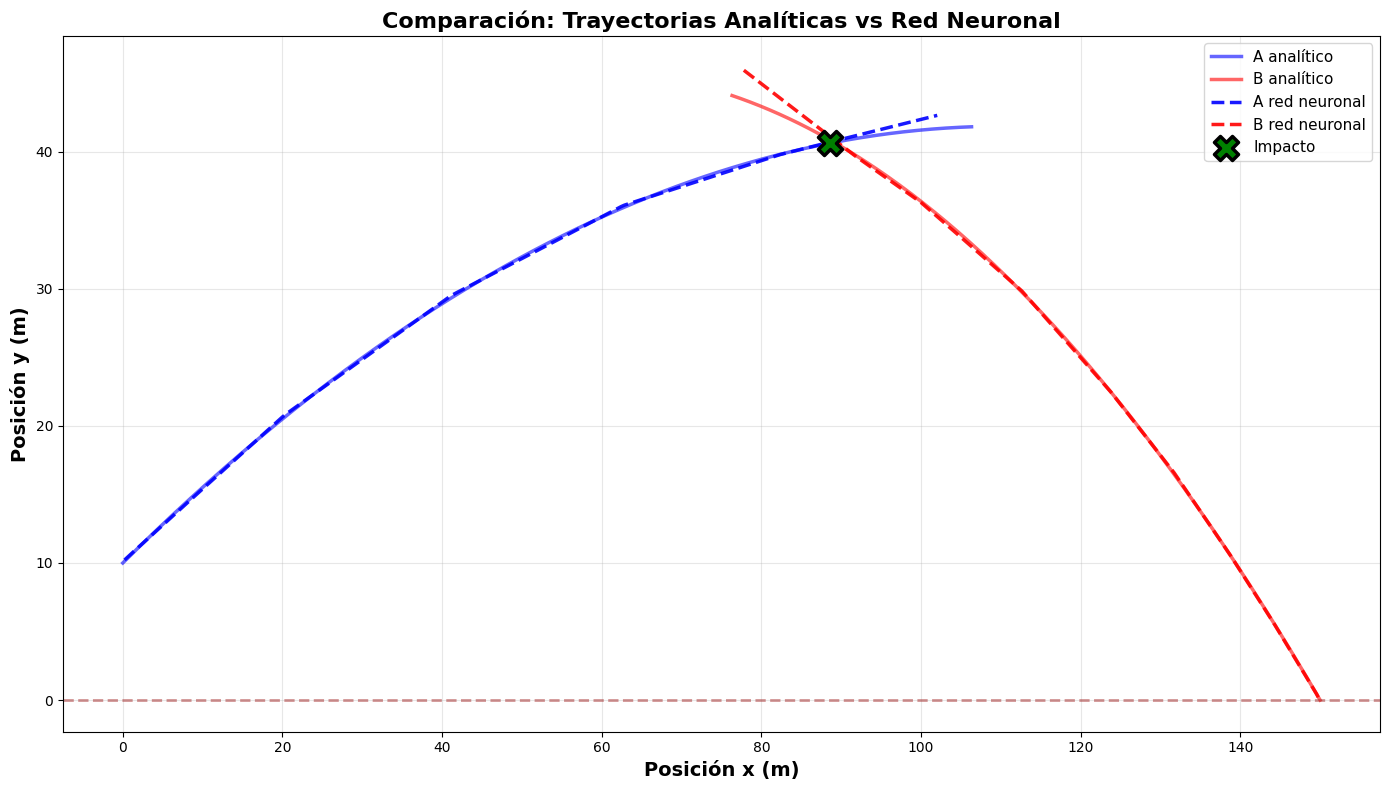

In [9]:
t_plot = np.linspace(0, t_impacto * 1.2, 300)
t_plot_norm = t_plot / (t_impacto * 1.2)

pred_A_norm = nn_A.predict(t_plot_norm.reshape(-1, 1), verbose=0)
pred_A = pred_A_norm * xy_A_std + xy_A_mean

pred_B_norm = nn_B.predict(t_plot_norm.reshape(-1, 1), verbose=0)
pred_B = pred_B_norm * xy_B_std + xy_B_mean

real_A = np.array([pos_A(t) for t in t_plot])
real_B = np.array([pos_B(t) for t in t_plot])

plt.figure(figsize=(14, 8))
plt.plot(real_A[:, 0], real_A[:, 1], 'b-', linewidth=2.5, alpha=0.6, label='A analítico')
plt.plot(real_B[:, 0], real_B[:, 1], 'r-', linewidth=2.5, alpha=0.6, label='B analítico')
plt.plot(pred_A[:, 0], pred_A[:, 1], 'b--', linewidth=2.5, alpha=0.9, label='A red neuronal')
plt.plot(pred_B[:, 0], pred_B[:, 1], 'r--', linewidth=2.5, alpha=0.9, label='B red neuronal')
plt.scatter([x_imp_A], [y_imp_A], color='green', s=300, marker='X', edgecolors='black', linewidth=2.5, zorder=6, label=f'Impacto')
plt.axhline(y=0, color='brown', linestyle='--', linewidth=2, alpha=0.5)
plt.xlabel('Posición x (m)', fontsize=14, fontweight='bold')
plt.ylabel('Posición y (m)', fontsize=14, fontweight='bold')
plt.title('Comparación: Trayectorias Analíticas vs Red Neuronal', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problema_3_nn_vs_analitico.png', dpi=300, bbox_inches='tight')
plt.show()

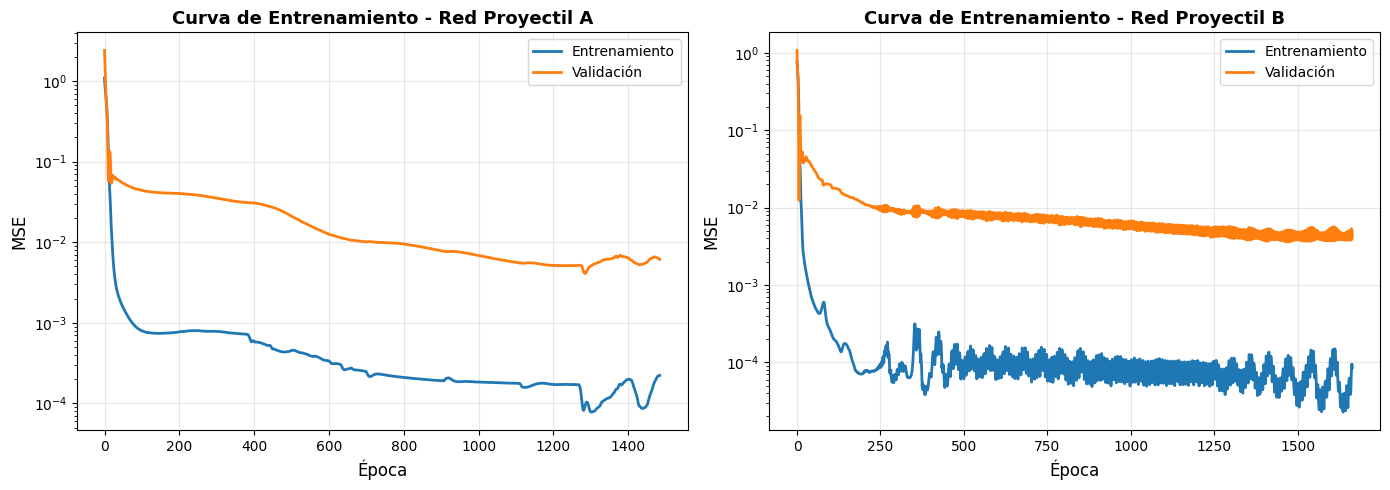

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist_A.history['loss'], label='Entrenamiento', linewidth=2)
if 'val_loss' in hist_A.history:
    ax1.plot(hist_A.history['val_loss'], label='Validación', linewidth=2)
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('MSE', fontsize=12)
ax1.set_title('Curva de Entrenamiento - Red Proyectil A', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

ax2.plot(hist_B.history['loss'], label='Entrenamiento', linewidth=2)
if 'val_loss' in hist_B.history:
    ax2.plot(hist_B.history['val_loss'], label='Validación', linewidth=2)
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('MSE', fontsize=12)
ax2.set_title('Curva de Entrenamiento - Red Proyectil B', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('problema_3_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 60)
print("RESULTADOS FINALES - COLISIÓN DE PROYECTILES")
print("=" * 60)
print(f"Tiempo de impacto:  t = {t_impacto:.6f} s")
print(f"Posición x impacto: x = {x_imp_A:.6f} m")
print(f"Posición y impacto: y = {y_imp_A:.6f} m")
print(f"\nVerificación:")
print(f"  |x_A - x_B| = {abs(x_imp_A - x_imp_B):.10f} m")
print(f"  |y_A - y_B| = {abs(y_imp_A - y_imp_B):.10f} m")

mse_A_x = np.mean((real_A[:, 0] - pred_A[:, 0])**2)
mse_A_y = np.mean((real_A[:, 1] - pred_A[:, 1])**2)
mse_B_x = np.mean((real_B[:, 0] - pred_B[:, 0])**2)
mse_B_y = np.mean((real_B[:, 1] - pred_B[:, 1])**2)

print(f"\nError de las redes neuronales:")
print(f"  Proyectil A - MSE x: {mse_A_x:.6f}, MSE y: {mse_A_y:.6f}")
print(f"  Proyectil B - MSE x: {mse_B_x:.6f}, MSE y: {mse_B_y:.6f}")

RESULTADOS FINALES - COLISIÓN DE PROYECTILES
Tiempo de impacto:  t = 2.046349 s
Posición x impacto: x = 88.609522 m
Posición y impacto: y = 40.618822 m

Verificación:
  |x_A - x_B| = 0.0000000000 m
  |y_A - y_B| = 0.2317462994 m

Error de las redes neuronales:
  Proyectil A - MSE x: 1.346208, MSE y: 0.030099
  Proyectil B - MSE x: 0.092406, MSE y: 0.219234
